In [1]:
# Importing all required libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import plotly.offline as py
import plotly.graph_objs as go
import seaborn as sns
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# For text processing
import nltk
from nltk.corpus import stopwords

# For building recommendation system
from sklearn.metrics.pairwise import linear_kernel
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
# Reading the dataset
zomato_data = pd.read_csv("../Dataset/zomato.csv")

# Make a copy so original data stays safe
zomato_df = zomato_data.copy()

# Preview first 2 rows
zomato_df.head(2)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari


In [3]:
# Check total rows and columns
print("Shape of dataset:", zomato_df.shape)

# Check all column names
print("\nColumns:", zomato_df.columns)

# Check data types and null counts
zomato_df.info()

Shape of dataset: (51717, 17)

Columns: Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object

In [4]:
# Check null values in each column
zomato_df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [6]:
# Fix rate column properly
# First convert to string
zomato_df['rate'] = zomato_df['rate'].astype(str)

# Remove '/5' from all values
zomato_df['rate'] = zomato_df['rate'].apply(lambda x: x.replace('/5', '').strip())

# Remove any remaining invalid values
zomato_df = zomato_df[zomato_df['rate'] != 'NEW']
zomato_df = zomato_df[zomato_df['rate'] != '-']
zomato_df = zomato_df[zomato_df['rate'] != 'nan']

# Now convert to float
zomato_df['rate'] = pd.to_numeric(zomato_df['rate'], errors='coerce')

# Drop any rows where rate is still null
zomato_df.dropna(subset=['rate'], inplace=True)

# Verify
print("Rate column sample:")
print(zomato_df['rate'].head())
print("\nRate data type:", zomato_df['rate'].dtype)

Rate column sample:
0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64

Rate data type: float64


In [7]:
# Check shape after cleaning
print("Shape after cleaning:", zomato_df.shape)

# Preview cleaned data
zomato_df.head()

Shape after cleaning: (41237, 14)


,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost,reviews_list,menu_item,type,city
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [8]:
# Clean the cost column
zomato_df['cost'] = zomato_df['cost'].astype(str)
zomato_df['cost'] = zomato_df['cost'].apply(lambda x: x.replace(',', '.'))
zomato_df['cost'] = pd.to_numeric(zomato_df['cost'], errors='coerce')

# Drop any rows where cost is null
zomato_df.dropna(subset=['cost'], inplace=True)

# Verify no null values remain
print("Null values after cleaning:")
print(zomato_df.isnull().sum())

print("\nShape after cleaning:", zomato_df.shape)

Null values after cleaning:
address         0
name            0
online_order    0
book_table      0
rate            0
votes           0
location        0
rest_type       0
cuisines        0
cost            0
reviews_list    0
menu_item       0
type            0
city            0
dtype: int64

Shape after cleaning: (41237, 14)


In [9]:
# Computing Mean Rating for each restaurant
from sklearn.preprocessing import MinMaxScaler

restaurants = list(zomato_df['name'].unique())
zomato_df['Mean Rating'] = 0

for i in range(len(restaurants)):
    zomato_df['Mean Rating'][zomato_df['name'] == restaurants[i]] = zomato_df['rate'][zomato_df['name'] == restaurants[i]].mean()

# Scaling the mean rating values between 1 and 5
scaler = MinMaxScaler(feature_range=(1, 5))
zomato_df[['Mean Rating']] = scaler.fit_transform(zomato_df[['Mean Rating']]).round(2)

# Check the result
print("Mean Rating sample:")
zomato_df[['name', 'rate', 'Mean Rating']].head()

Mean Rating sample:


,name,rate,Mean Rating
0,Jalsa,4.1,3.99
1,Spice Elephant,4.1,3.97
2,San Churro Cafe,3.8,3.58
3,Addhuri Udupi Bhojana,3.7,3.45
4,Grand Village,3.8,3.58


In [10]:
# Download stopwords
import nltk
nltk.download('stopwords')

# Step 1: Lower casing reviews
zomato_df['reviews_list'] = zomato_df['reviews_list'].str.lower()

# Step 2: Remove punctuations
import string
PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

zomato_df['reviews_list'] = zomato_df['reviews_list'].apply(
    lambda text: remove_punctuation(text)
)

# Step 3: Remove stopwords
STOPWORDS = set(stopwords.words('english'))
def remove_stopwords(text):
    return " ".join([word for word in str(text).split() 
                    if word not in STOPWORDS])

zomato_df['reviews_list'] = zomato_df['reviews_list'].apply(
    lambda text: remove_stopwords(text)
)

# Verify
print("Sample cleaned reviews:")
zomato_df[['reviews_list', 'cuisines']].sample(3)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Sample cleaned reviews:


,reviews_list,cuisines
1279,rated 20 ratedn shifting mahadevapura used sta...,"Fast Food, Rolls, Momos"
30860,rated 30 ratedn hotel yesterdaynthe buffet gre...,"Chinese, North Indian, Cafe"
33779,rated 50 ratedn main land china number times b...,Chinese


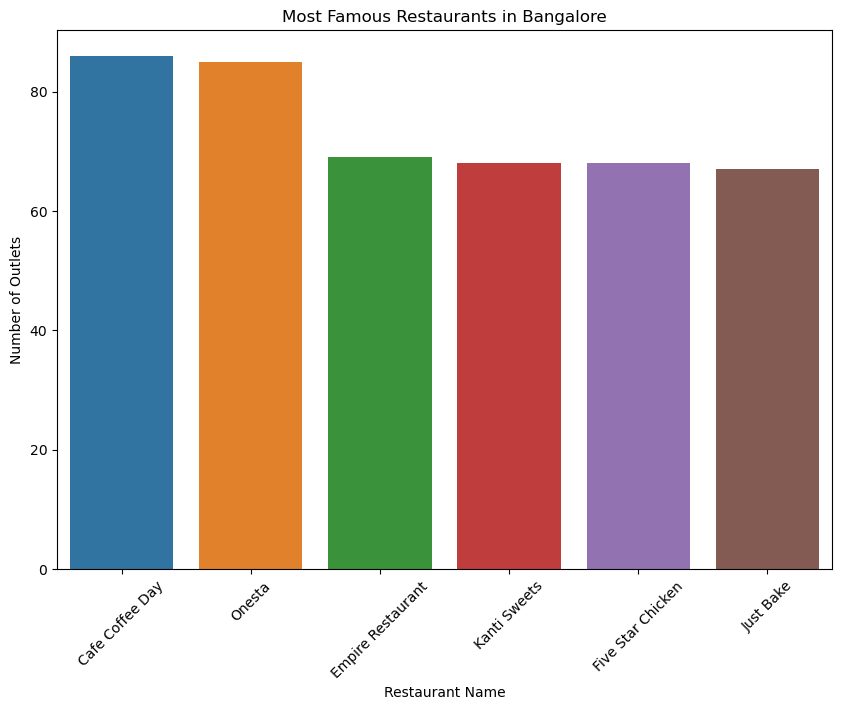

In [11]:
# Top 6 most famous restaurants by number of outlets
plt.figure(figsize=(10, 7))
chains = zomato_df['name'].value_counts()[:6]
sns.barplot(x=chains.index, y=chains, palette='tab10')
plt.title("Most Famous Restaurants in Bangalore")
plt.xlabel("Restaurant Name")
plt.ylabel("Number of Outlets")
plt.xticks(rotation=45)
plt.show()

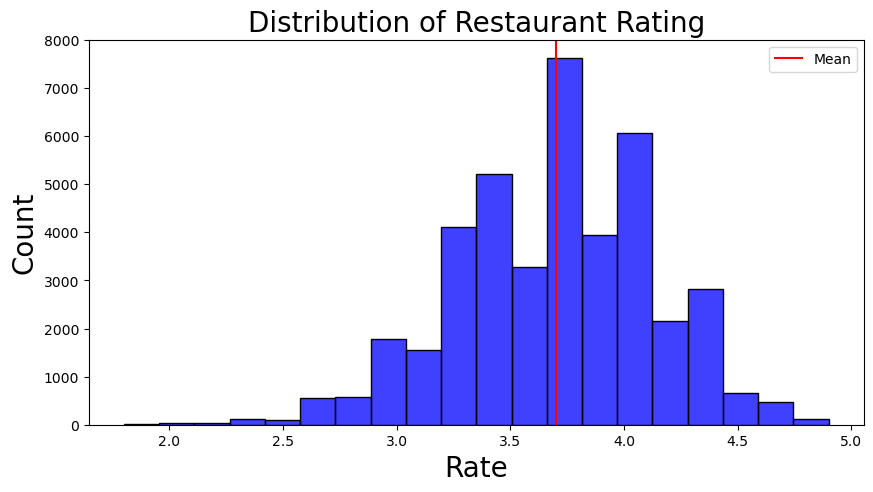

In [12]:
# Distribution of restaurant ratings
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
sns.histplot(zomato_df.rate, color='b', ax=ax, bins=20)
ax.axvline(zomato_df.rate.mean(), 0, 1, color='r', label='Mean')
ax.legend()
ax.set_ylabel('Count', size=20)
ax.set_xlabel('Rate', size=20)
ax.set_title('Distribution of Restaurant Rating', size=20)
plt.show()

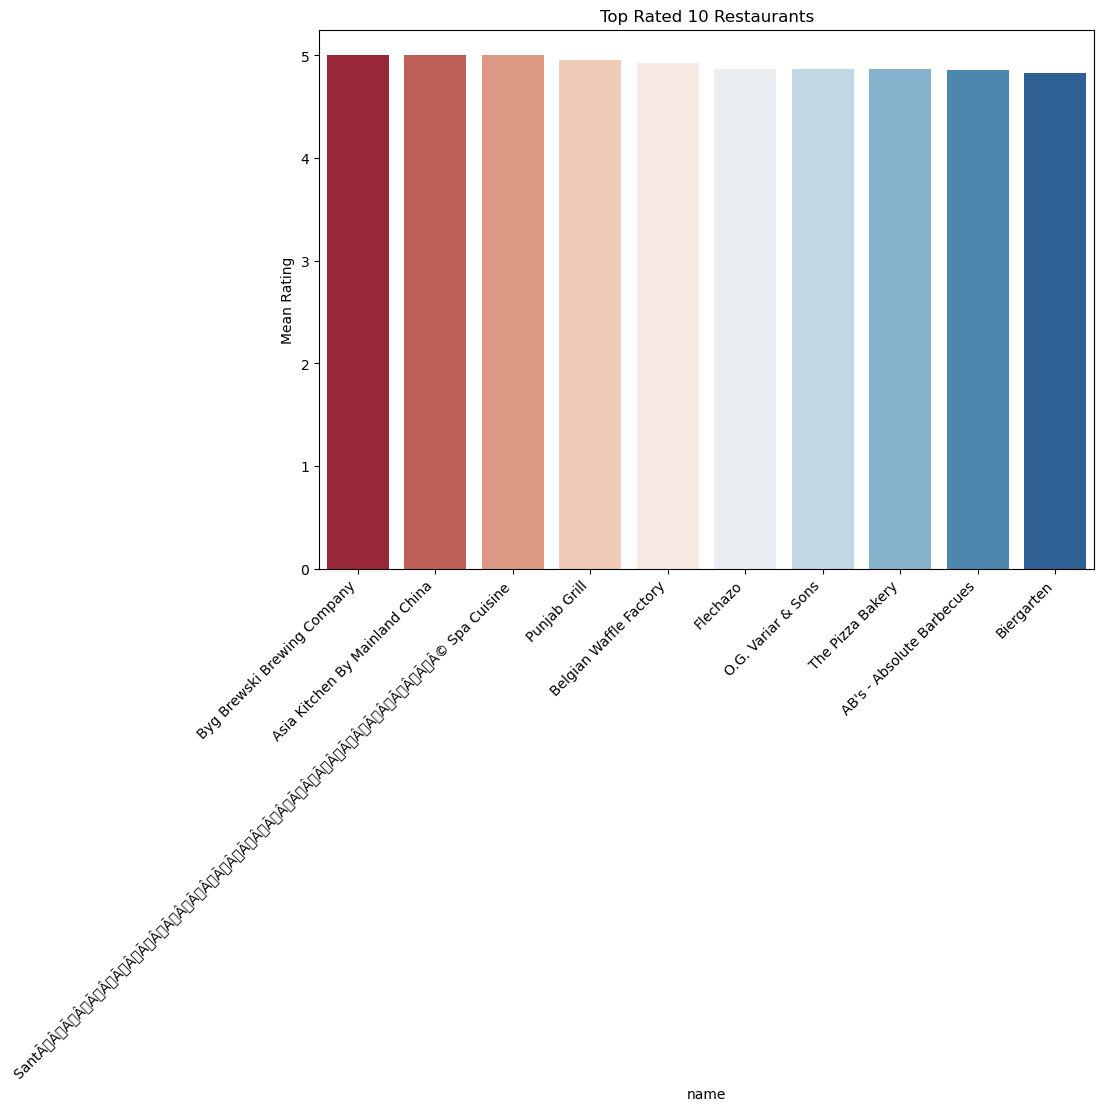

In [13]:
# Top 10 rated restaurants
df_rating = zomato_df.drop_duplicates(subset='name')
df_rating = df_rating.sort_values(by='Mean Rating', ascending=False).head(10)
plt.figure(figsize=(10, 7))
sns.barplot(data=df_rating, y='Mean Rating', x='name', palette='RdBu')
plt.xticks(rotation=45, ha='right')
plt.title('Top Rated 10 Restaurants')
plt.show()

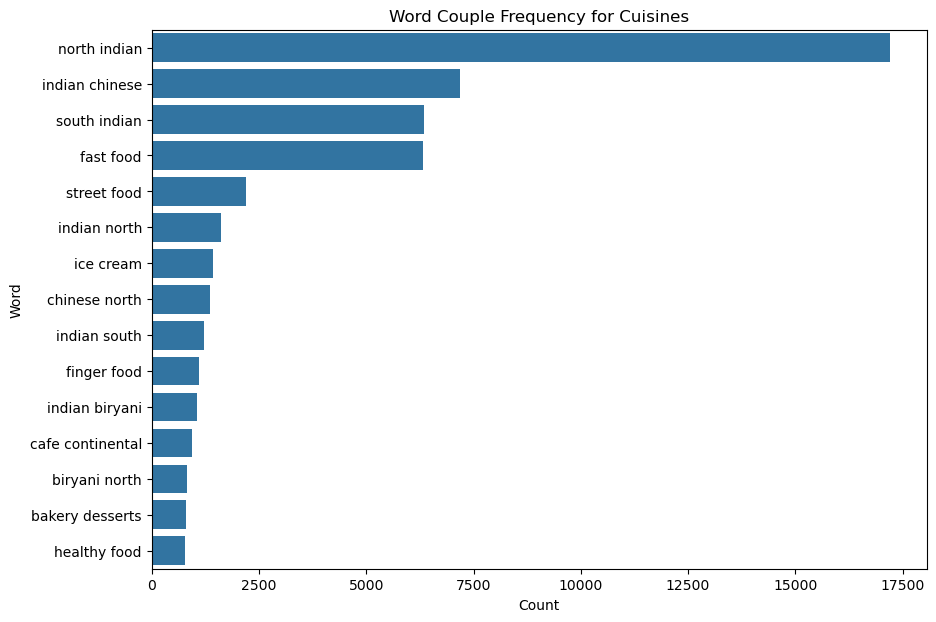

In [14]:
# Top 15 cuisine word frequencies
from collections import Counter

def get_top_words(series, n, ngram):
    vec = CountVectorizer(ngram_range=ngram).fit(series)
    bag_of_words = vec.transform(series)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) 
                  for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

lst = get_top_words(zomato_df['cuisines'], 15, (2, 2))
df_words = pd.DataFrame(lst, columns=['Word', 'Count'])
plt.figure(figsize=(10, 7))
sns.barplot(data=df_words, x='Count', y='Word')
plt.title('Word Couple Frequency for Cuisines')
plt.show()

In [15]:
# Setting restaurant name as index
df_percent = zomato_df.sample(frac=0.5)
df_percent.set_index('name', inplace=True)
indices = pd.Series(df_percent.index)

# Creating TF-IDF matrix
tfidf = TfidfVectorizer(analyzer='word',
                        ngram_range=(1, 2),
                        min_df=0,
                        stop_words='english')

tfidf_matrix = tfidf.fit_transform(df_percent['reviews_list'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

InvalidParameterError: The 'min_df' parameter of TfidfVectorizer must be a float in the range [0.0, 1.0] or an int in the range [1, inf). Got 0 instead.

In [16]:
# Setting restaurant name as index
df_percent = zomato_df.sample(frac=0.5)
df_percent.set_index('name', inplace=True)
indices = pd.Series(df_percent.index)

# Creating TF-IDF matrix (min_df changed from 0 to 1)
tfidf = TfidfVectorizer(analyzer='word',
                        ngram_range=(1, 2),
                        min_df=1,
                        stop_words='english')

tfidf_matrix = tfidf.fit_transform(df_percent['reviews_list'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (20618, 1364897)


In [17]:
# Test with different restaurants
recommend('Jalsa')

NameError: name 'recommend' is not defined

In [18]:
# Computing cosine similarity
cosine_similarities = linear_kernel(tfidf_matrix, tfidf_matrix)

print("Cosine Similarity Matrix Shape:", cosine_similarities.shape)

Cosine Similarity Matrix Shape: (20618, 20618)


In [19]:
def recommend(name, cosine_similarities=cosine_similarities):
    
    # Create a list to store recommended restaurants
    recommend_restaurant = []
    
    # Find the index of the restaurant entered
    idx = indices[indices == name].index[0]
    
    # Find restaurants with similar cosine similarity
    # and sort from highest to lowest
    score_series = pd.Series(
        cosine_similarities[idx]
    ).sort_values(ascending=False)
    
    # Extract top 30 restaurant indexes
    top30_indexes = list(score_series.iloc[0:31].index)
    
    # Get names of top 30 restaurants
    for each in top30_indexes:
        recommend_restaurant.append(list(df_percent.index)[each])
    
    # Create new dataframe with similar restaurants
    df_new = pd.DataFrame(columns=['cuisines', 'Mean Rating', 'cost'])
    
    # Get top 30 similar restaurants with their details
    for each in recommend_restaurant:
        df_new = df_new._append(
            pd.DataFrame(
                df_percent[['cuisines', 'Mean Rating', 'cost']][
                    df_percent.index == each
                ].sample()
            )
        )
    
    # Drop duplicates and sort by highest rating
    df_new = df_new.drop_duplicates(
        subset=['cuisines', 'Mean Rating', 'cost'],
        keep=False
    )
    df_new = df_new.sort_values(
        by='Mean Rating',
        ascending=False
    ).head(10)
    
    print('TOP %s RESTAURANTS LIKE %s WITH SIMILAR REVIEWS: ' % (
        str(len(df_new)), name
    ))
    
    return df_new

In [20]:
recommend('Jalsa')

TOP 10 RESTAURANTS LIKE Jalsa WITH SIMILAR REVIEWS: 


,cuisines,Mean Rating,cost
Byg Brewski Brewing Company,"Continental, North Indian, Italian, South Indi...",5.00,1.6
Biergarten,"Continental, European, BBQ, Chinese, Asian",4.83,2.4
House Of Commons,"Continental, Asian, North Indian",4.77,1.0
Communiti,"Continental, BBQ, Salad",4.67,1.5
Brew and Barbeque - A Microbrewery Pub,"Continental, North Indian, BBQ, Steak",4.64,1.4
Vapour Brewpub and Diner,"North Indian, Continental, Italian",4.54,1.4
The Globe Grub,"Continental, North Indian, Asian, Italian",4.48,1.3
Buff Buffet Buff,"North Indian, Chinese, Continental, Thai, Salad",4.48,1.5
Delhi Highway,North Indian,4.41,1.2
Delhi Highway,"North Indian, Mughlai",4.41,1.5


In [21]:
recommend('Cinnamon')

TOP 10 RESTAURANTS LIKE Cinnamon WITH SIMILAR REVIEWS: 


,cuisines,Mean Rating,cost
Eggzotic,"North Indian, Chinese, Biryani, Fast Food",3.77,500.0
Atithi,North Indian,3.63,750.0
Atithi,"North Indian, Chinese, Street Food",3.63,800.0
Pallavi Restaurant,"Biryani, Chinese, Andhra",3.58,500.0
Fazzito Kitchen,North Indian,3.58,700.0
Hunger Hitman,"North Indian, Chinese",3.58,300.0
Desi Doze,"North Indian, Fast Food",3.58,400.0
Red Chilliez,"North Indian, South Indian, Chinese, Seafood",3.26,550.0
Desi Dhaba,"North Indian, Chinese",3.19,400.0
Aaranya Restaurant,"North Indian, Chinese, Mughlai",3.06,800.0


In [22]:
recommend('Spice up')

IndexError: index 0 is out of bounds for axis 0 with size 0

In [23]:
# Check all available restaurant names
available_restaurants = list(df_percent.index.unique())
print("Total restaurants available:", len(available_restaurants))
print("\nFirst 20 restaurants:")
print(available_restaurants[:20])

Total restaurants available: 5721

First 20 restaurants:
['New Udupi Grand', 'Shree Sadguru Refreshment', 'The Irish House', 'Shawarma Inc', 'New Mahesh Friends Food Corner', 'Guzzlers Inn', 'KKR Foodies', 'Shawarma Time', 'Starbucks', 'Amaravati', 'Hot Rolls & House Of Kebabs', 'Chowpatty', 'WTF', 'Sangam Mess', 'Painted Platters', "David's Kitchen", 'Eatsaa', 'Chettayees', 'Sichuan', 'South Point Pub']


In [24]:
# Search if a restaurant exists before recommending
def search_restaurant(keyword):
    results = [r for r in available_restaurants 
               if keyword.lower() in r.lower()]
    print("Restaurants found:")
    for r in results[:10]:
        print("-", r)

# Try searching
search_restaurant('Spice')

Restaurants found:
- Mountain Spice
- Sunny Spice Chinese Restaurant
- Southern Spice
- Deccan Spice
- Spice Corner
- Urban Spice
- Ice & Spice
- iSpice Resto Cafe
- Sutra Spice-The Resto Bar
- Saara's Grill n Spice - SS Lumina Hotel


In [25]:
# Use exact name from search results above
recommend('Jalsa')

TOP 10 RESTAURANTS LIKE Jalsa WITH SIMILAR REVIEWS: 


,cuisines,Mean Rating,cost
Byg Brewski Brewing Company,"Continental, North Indian, Italian, South Indi...",5.00,1.6
Biergarten,"Continental, European, BBQ, Chinese, Asian",4.83,2.4
House Of Commons,"Continental, Asian, North Indian",4.77,1.0
Communiti,"Continental, BBQ, Salad",4.67,1.5
Brew and Barbeque - A Microbrewery Pub,"Continental, North Indian, BBQ, Steak",4.64,1.4
Vapour Brewpub and Diner,"North Indian, Continental, Italian",4.54,1.4
The Globe Grub,"Continental, North Indian, Asian, Italian",4.48,1.3
Buff Buffet Buff,"North Indian, Chinese, Continental, Thai, Salad",4.48,1.5
Delhi Highway,North Indian,4.41,1.2
Delhi Highway,"North Indian, Mughlai",4.41,1.5


In [26]:
# Save the cleaned dataset to Flask folder
zomato_df.to_csv('../Flask/restaurant1.csv', index=False)
df_percent.to_csv('../Flask/restaurant_percent.csv')

print("Dataset saved successfully!")

Dataset saved successfully!


In [27]:
import pickle

# Save the cosine similarity matrix
pickle.dump(cosine_similarities, 
            open('../Flask/cosine_similarities.pkl', 'wb'))

# Save the indices
pickle.dump(indices, 
            open('../Flask/indices.pkl', 'wb'))

print("Model saved successfully!")

Model saved successfully!
